In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator
import seaborn as sns

In [89]:
df = pd.read_csv("ec2_cpu_utilization_5f5533.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])

**Rolling Average (carried over from other file)**

In [90]:
# 144 window, 5 mins, rolling avg every 12 hrs
df["12_hr_avg"] = df["value"].rolling(window=144).mean()
df["12_hr_sd"] = df["value"].rolling(window=144).std()

**Basic CSV over time graph**

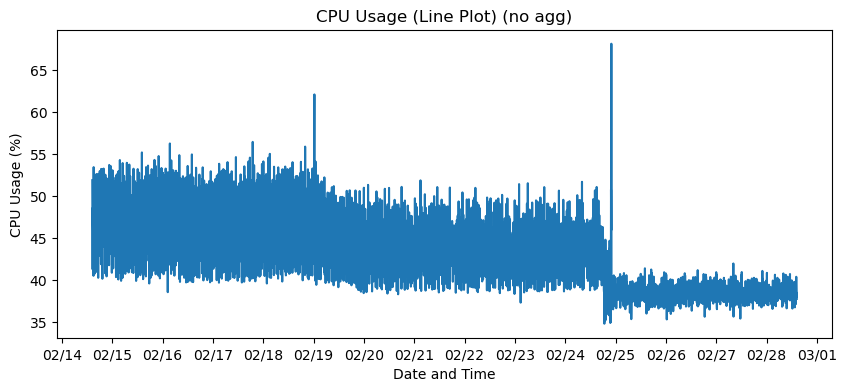

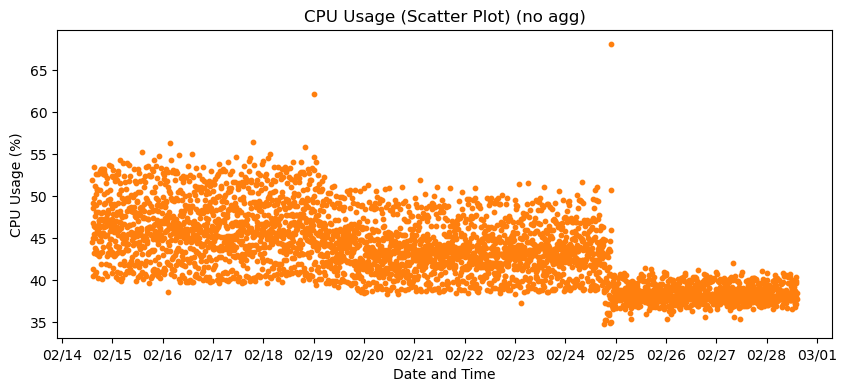

In [91]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

# line chart
fig1, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(df["timestamp"], df["value"], color="tab:blue")
ax1.set_title("CPU Usage (Line Plot) (no agg)")
ax1.set_xlabel("Date and Time")
ax1.set_ylabel("CPU Usage (%)")
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))

# scatter chart
fig2, ax2 = plt.subplots(figsize=(10, 4))
ax2.scatter(df["timestamp"], df["value"], color="tab:orange", s=10)
ax2.set_title("CPU Usage (Scatter Plot) (no agg)")
ax2.set_xlabel("Date and Time")
ax2.set_ylabel("CPU Usage (%)")
ax2.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))

plt.show()

Spikes at the end of 02/19 and 02/24. Also slight drop from 02/19 to 02/20 and even more from 02/24 to 02/25.
But does not drop too much, so computers might be running something moderately heavy even after the drop.

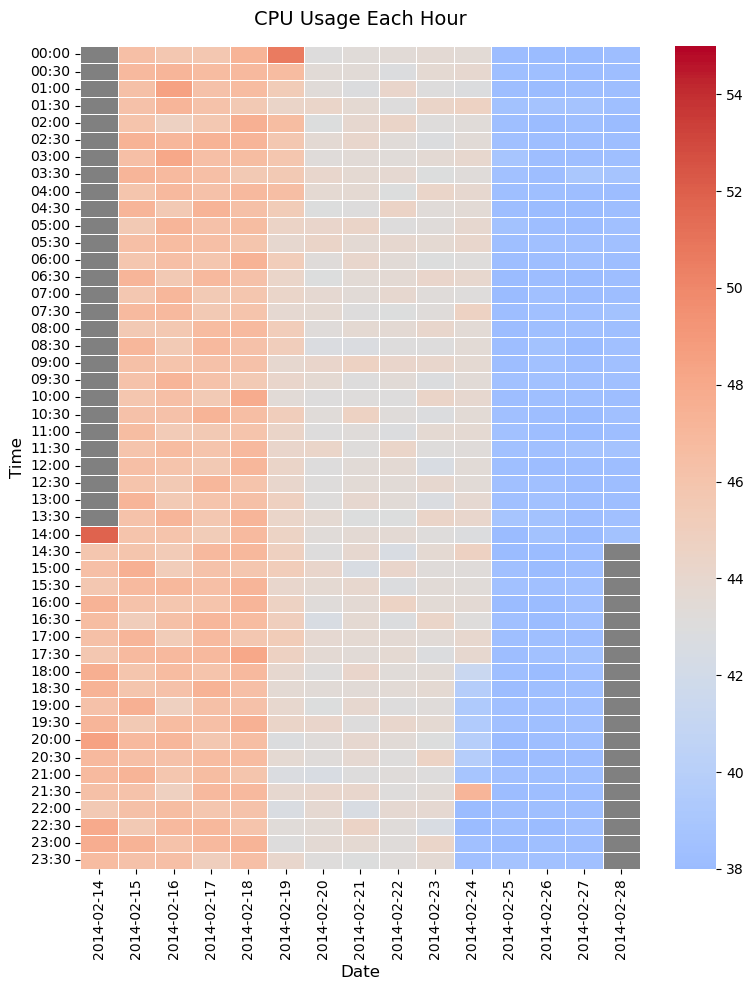

In [92]:
# Turn into a heatmap (columns = dates, rows = times)
df_flat = pd.DataFrame({
    "timestamp": pd.to_datetime(df["timestamp"]),
    "cpu_usage": df["value"]
})

df_flat["timestamp_h"] = df_flat["timestamp"].dt.floor("30min")

df_flat["Date"] = df_flat["timestamp_h"].dt.date
df_flat["Time"] = df_flat["timestamp_h"].dt.strftime('%H:%M')

# Pivot the table: rows = Time, columns = Date
df_pivoted = df_flat.pivot_table(
    index="Time", 
    columns="Date", 
    values="cpu_usage",  
    aggfunc="mean"  
)

# Turn this into a heatmap
fig2, ax2 = plt.subplots(figsize=(8, 10))
sns.heatmap(
    df_pivoted,
    cmap="coolwarm",
    linewidths=0.5,
    vmin=38, vmax=55,
    center=43,
    ax=ax2
)

ax2.set_title("CPU Usage Each Hour", fontsize=14, pad=15)
ax2.set_xlabel("Date", fontsize=12)
ax2.set_ylabel("Time", fontsize=12)
ax2.set_facecolor("gray")

plt.tight_layout()
plt.show()

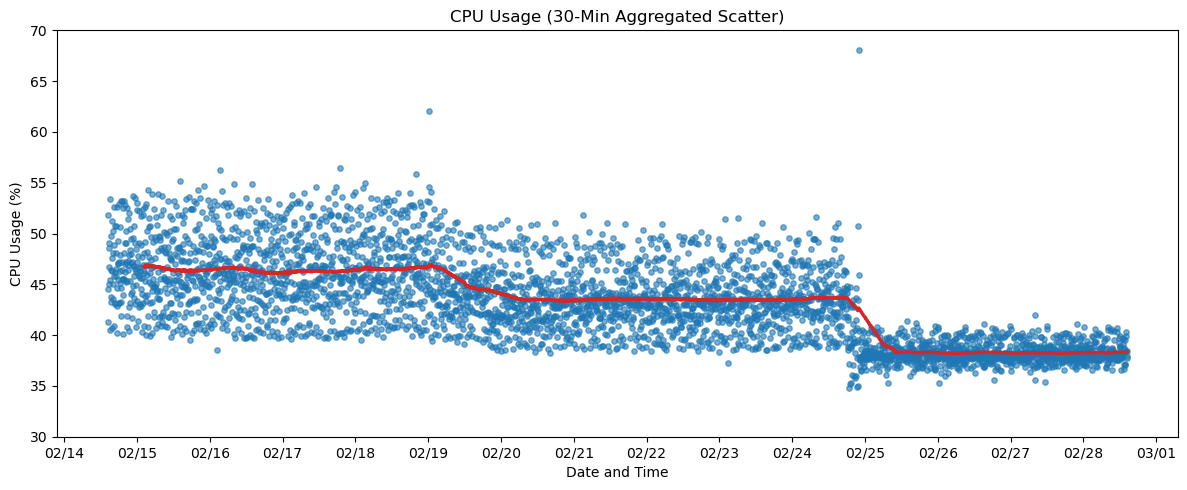

In [93]:
fig1, ax1 = plt.subplots(figsize=(12, 5))

# Use the grouped/floored timestamp column directly
ax1.scatter(
    df_flat["timestamp"], 
    df_flat["cpu_usage"], 
    color="tab:blue", 
    alpha=0.6, 
    s=15
)

ax1.plot(
   df["timestamp"],
   df["12_hr_avg"],
   color="tab:red",
   linewidth=2.5,
   label="Unagg Rolling Avg" 
)

ax1.set_title("CPU Usage (30-Min Aggregated Scatter)")
ax1.set_xlabel("Date and Time")
ax1.set_ylabel("CPU Usage (%)")
ax1.set_ylim(30, 70)

ax1.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))

plt.tight_layout()
plt.show()

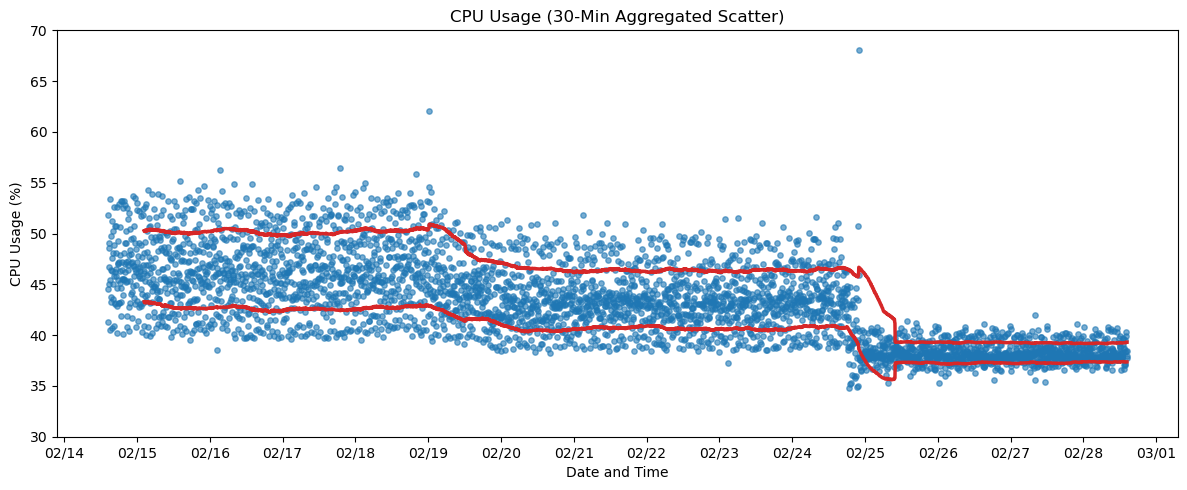

In [96]:
fig1, ax1 = plt.subplots(figsize=(12, 5))

# Use the grouped/floored timestamp column directly
ax1.scatter(
    df_flat["timestamp"], 
    df_flat["cpu_usage"], 
    color="tab:blue", 
    alpha=0.6, 
    s=15
)

df["lower1SD"] = df["12_hr_avg"] - (1 * df["12_hr_sd"])
df["upper1SD"] = df["12_hr_avg"] + (1 * df["12_hr_sd"])

ax1.plot(
   df["timestamp"],
   df["lower1SD"],
   color="tab:red",
   linewidth=2.5,
   label="Unagg Rolling Avg" 
)

ax1.plot(
   df["timestamp"],
   df["upper1SD"],
   color="tab:red",
   linewidth=2.5,
   label="Unagg Rolling Avg" 
)

ax1.set_title("CPU Usage (30-Min Aggregated Scatter)")
ax1.set_xlabel("Date and Time")
ax1.set_ylabel("CPU Usage (%)")
ax1.set_ylim(30, 70)

ax1.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))

plt.tight_layout()
plt.show()